<a href="https://colab.research.google.com/github/uu-sml/wasp-assigninmen-af-classification/blob/main/assignment_ecg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comment out cell below to use the old model.

In [1]:
import os
file_path = 'model.pth'

# if os.path.exists(file_path):
#     os.remove(file_path)
#     print(f"Successfully deleted {file_path}")
# else:
#     print(f"File {file_path} does not exist.")

In [2]:
import os, shutil, subprocess, stat

# helper function
def exists(path):
    val = os.path.exists(path)
    if val:
        print(f'{path} already exits. Using cached. Delete it manually to recieve it again!')
    return val

def _rm_readonly(func, path, _):
    os.chmod(path, stat.S_IWRITE)
    func(path)

# Only download requirements.txt if not already cached
if not exists('requirements.txt'):
    if os.path.exists('req'):
        shutil.rmtree('req', onerror=_rm_readonly)
    subprocess.run(['git', 'clone', 'https://gist.github.com/dgedon/8a7b91714568dc35d0527233e9ceada4.git', 'req'], check=True)
    shutil.copy('req/requirements.txt', 'requirements.txt')
    shutil.rmtree('req', onerror=_rm_readonly)

# Read requirements.txt and remove all version constraints
with open('requirements.txt', 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    if '==' in line:
        new_lines.append(line.split('==')[0] + '\n')
    else:
        new_lines.append(line)

with open('requirements.txt', 'w') as f:
    f.writelines(new_lines)

print('Modified requirements.txt: removed all version constraints.')


requirements.txt already exits. Using cached. Delete it manually to recieve it again!
Modified requirements.txt: removed all version constraints.


In [3]:
# Install packages (python>=3.9 is required)
# %pip install -r requirements.txt

In [4]:
# Import
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
#from tqdm.auto import trange, tqdm
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import ast
from PIL import Image
import glob
%matplotlib inline

In [5]:
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))
    x = torch.randn(2, 2).to("cuda")
    print("Tensor device:", x.device)

CUDA available: True
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 3060 Ti
Tensor device: cuda:0


### Preprocessing

In [6]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

set_data = 'L' # L = large, S = small
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

if set_data == 'S':
    h5_names = ['test_s.h5', 'train_s.h5']
else:
    h5_names = ['test_l.h5', 'train_l.h5']

try:
    f1 = h5py.File(h5_names[0], 'r')
    f2 = h5py.File(h5_names[1], 'r')
    print('Files exist')
    f1.close()
    f2.close()
except FileNotFoundError:

    path = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\'
    sampling_rate=100

    # load and convert annotation data
    Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
    Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

    # Load raw signal data
    #X = load_raw_data(Y, sampling_rate, path)

    # Load scp_statements.csv for diagnostic aggregation
    agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1]

    def aggregate_diagnostic(y_dic):
        tmp = []
        for key in y_dic.keys():
            if key in agg_df.index:
                tmp.append(agg_df.loc[key].diagnostic_class)
        return list(set(tmp))

    # Apply diagnostic superclass
    Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

    # Split data into train and test
    test_fold = 10
    # Train
    #X_train = X[np.where(Y.strat_fold != test_fold)]
    y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
    # Test
    #X_test = X[np.where(Y.strat_fold == test_fold)]
    y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

    png_folder_path = r"..\output-images" + "\\"
    png_paths = sorted(glob.glob(png_folder_path + "*.png"))

    arrays_train = []
    arrays_test = []
    png_paths_test = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_test.index.tolist()]
    png_paths_train = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_train.index.tolist()]
    
    data_size = 0
    if set_data == 'S':
        data_size = 500
        print('Using small dataset...')
    elif set_data == 'L':
        data_size = len(png_paths)
        print('Using large dataset...')
    else:
        print('Error: No dataset specified')
        raise SystemExit  # Stops execution
        
    ratio = len(png_paths_test)/len(png_paths)
    print(f'Division of test data vs train data: {ratio}')
    data_size_test = int(ratio*data_size)
    data_size_train = data_size - data_size_test
    png_paths_test = png_paths_test[:data_size_test]
    png_paths_train = png_paths_train[:data_size_train]
    
    print(data_size)
    print(data_size_test)
    print(data_size_train)

    for p in png_paths_test:
        img = Image.open(p).convert("L")
        arrays_test.append(np.array(img))

    for p in png_paths_train:
        img = Image.open(p).convert("L")
        arrays_train.append(np.array(img))

    arrays_test = np.stack(arrays_test)
    arrays_train = np.stack(arrays_train)

    arrays_test = arrays_test / 255
    arrays_train = arrays_train / 255
    
    H = arrays_train.shape[1]
    arrays_test = arrays_test[:,int(0.275*H):,:]
    arrays_train = arrays_train[:,int(0.275*H):,:]
    
    y_test = y_test.iloc[0:].to_list()
    y_train = y_train.iloc[0:].to_list()

    for i in range(len(y_test)):
        lst = np.zeros(len(classes))
        z = 0
        for j in classes:
            if j in y_test[i]:
                lst[z] = 1
            z+=1
        y_test[i] = lst

    for i in range(len(y_train)):
        lst = np.zeros(len(classes))
        z = 0
        for j in classes:
            if j in y_train[i]:
                lst[z] = 1
            z+=1
        y_train[i] = lst

    y_test = np.stack(y_test)
    y_train = np.stack(y_train)

    y_test = y_test[:arrays_test.shape[0]]
    y_train = y_train[:arrays_train.shape[0]]

    with h5py.File(h5_names[0], "w") as h5f_test:
        h5f_test.create_dataset("images", data=arrays_test, compression="gzip")
        h5f_test.create_dataset("labels", data=y_test, compression='gzip')

    with h5py.File(h5_names[1], "w") as h5f_train:
        h5f_train.create_dataset("images", data=arrays_train, compression="gzip")
        h5f_train.create_dataset("labels", data=y_train, compression='gzip')

    print("Files created successfully")

    print(y_test.shape)
    print(arrays_test.shape)
    print(y_train.shape)
    print(arrays_train.shape)
    
    plt.imshow(arrays_train[0], cmap='gray')
    plt.show()

Files exist


#### High Res h5 generation

In [7]:



# path = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\'
# sampling_rate=100

# # load and convert annotation data
# Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
# Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# # Load raw signal data
# #X = load_raw_data(Y, sampling_rate, path)

# # Load scp_statements.csv for diagnostic aggregation
# agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
# agg_df = agg_df[agg_df.diagnostic == 1]

# def aggregate_diagnostic(y_dic):
#     tmp = []
#     for key in y_dic.keys():
#         if key in agg_df.index:
#             tmp.append(agg_df.loc[key].diagnostic_class)
#     return list(set(tmp))

# # Apply diagnostic superclass
# Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# # Split data into train and test
# test_fold = 10
# # Train
# #X_train = X[np.where(Y.strat_fold != test_fold)]
# y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# # Test
# #X_test = X[np.where(Y.strat_fold == test_fold)]
# y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass




# # png_folder_path = r"..\..\output_images_50" + "\\"
# png_folder_path = r"..\output-images" + "\\"
# png_paths = sorted(glob.glob(png_folder_path + "*.png"))

# png_paths_test = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_test.index.tolist()]
# png_paths_train = [x for x in png_paths if int(x.split('\\')[-1].split('_')[0]) in y_train.index.tolist()]


# y_test = y_test.iloc[0:].to_list()
# y_train = y_train.iloc[0:].to_list()

# y_test = y_test[:]
# y_train = y_train[:]

# # print(len(png_paths_test), len(y_test), y_test[0])

# for i in range(len(y_test)):
#     lst = np.zeros(len(classes))
#     z = 0
#     for j in classes:
#         if j in y_test[i]:
#             lst[z] = 1
#         z+=1
#     y_test[i] = lst

# for i in range(len(y_train)):
#     lst = np.zeros(len(classes))
#     z = 0
#     for j in classes:
#         if j in y_train[i]:
#             lst[z] = 1
#         z+=1
#     y_train[i] = lst


# y_test = np.stack(y_test)
# y_train = np.stack(y_train)

# y_test = y_test[:]
# y_train = y_train[:]

# print(len(png_paths_train), y_train.shape)

def images_to_h5_compressed(png_paths, h5_path, label_data, img_preshape, batch_size=64):
    """
    Converts images to a compressed h5 file in batches to manage RAM.
    """
    
    
    H = img_preshape[0]
    dummy=np.zeros(img_preshape)
    img_shape=(H - int(0.275*H),img_preshape[1])
    
    
    # 1. Get file list
    
    total_images = len(png_paths)

    print(f"Found {total_images} images. Starting compression...")

    with h5py.File(h5_path, "w") as f:
        
        # 2. Create Dataset with Compression
        # chunks=(batch_size, ...) aligns the file storage with our processing loop.
        # This makes the gzip compression much faster.
        dset = f.create_dataset(
            "images", 
            shape=(total_images, *img_shape), 
            dtype='float32',
            compression="gzip",
            chunks=(batch_size, *img_shape) 
        )

        dset_5d = f.create_dataset("labels", 
                                    shape=(total_images, 5), 
                                    dtype='float32', 
                                    compression="gzip", 
                                    chunks=(batch_size, 5))
        
        # 3. Process in Batches
        # We step through the list in jumps of 'batch_size'
        for i in range(0, total_images, batch_size):
            
            # Define the current batch range
            png_paths_batch = png_paths[i : i + batch_size]
            array_batch = []
            labels_batch=[]
            
            # Load images for this specific batch
            for p in png_paths_batch:
                try:
                    img = Image.open(p).convert("L")
                    array_batch.append(np.array(img))
                except Exception as e:
                    print(f"Error reading {p}: {e}")
                    # Handle error: append zeros or skip (skipping requires resizing dataset)
                    # For now, we assume data integrity or append zeros
                    array_batch.append(np.zeros(img_shape, dtype='uint8'))

            # Stack this batch into a single numpy array
            # RAM usage spikes here, but only for 'batch_size' images (not 20,000)
            array_batch = np.stack(array_batch, axis=0)/247
            
            H = array_batch.shape[1]
            array_batch = array_batch[:,int(0.275*H):,:]
            
            
            # Write the batch to the H5 file
            # This triggers the gzip compression for this chunk
            dset[i : i + len(png_paths_batch)] = array_batch
            dset_5d[i:i + len(png_paths_batch)] = label_data[i : i + len(png_paths_batch)]
            
            print(f"Saved batch {i} to {i + len(png_paths_batch)} / {total_images}", end='\r')

        print(f"\n\nSuccess! Saved to {h5_path}")
        print(f"Dataset Shape: {dset.shape}")
        print(f"Dataset Chunks: {dset.chunks}")


# images_to_h5_compressed(
#     png_paths=png_paths_test,
#     h5_path='test_50.h5',
#     label_data=y_test, 
#     img_preshape=(425,550),
#     batch_size=128
# )

# images_to_h5_compressed(
#     png_paths=png_paths_train,
#     h5_path='train_lowres.h5',
#     label_data=y_train, 
#     img_preshape=(255,330),
#     batch_size=128
# )

In [8]:
# Path to the training CSV file
path_to_csv_train = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv'

# Load the CSV file into a DataFrame
df_train_labels = pd.read_csv(path_to_csv_train)
'''
print("\nDistribution of AF (Atrial Fibrillation) labels:")
display(df_train_labels['AF'].value_counts())
'''
# 0 = male, 1 = female
print("\nDistribution of Sex:")
display(df_train_labels['sex'].value_counts())

print("\nDistribution of Age:")
display(df_train_labels['age'].describe())


Distribution of Sex:


sex
0    11354
1    10445
Name: count, dtype: int64


Distribution of Age:


count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64

### Define your model



In [9]:
from torchvision import models

# Resnet

class Model(nn.Module):
    def __init__(self,):
        super(Model, self).__init__()
        self.kernel_size = 3
        
        # self.input_dim = (dimensions[0], dimensions[1]) #(425, 550) right now

        self.output_dim = None
        try:
            classes
            self.output_dim = len(classes)
            
        except NameError:
            self.output_dim = 5  # default value
            
        

        # initial_in_channels = 1 
        # h_dim = self.input_dim[0]
        # w_dim = self.input_dim[1]
        out_dim = self.output_dim
        
        #https://www.geeksforgeeks.org/machine-learning/ml-getting-started-with-alexnet/

        resnet = models.resnet50()
        
        original_first_layer = resnet.conv1
        resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=original_first_layer.out_channels,
            kernel_size=original_first_layer.kernel_size,
            stride=original_first_layer.stride,
            padding=original_first_layer.padding,
            bias=False
        )

        num_features = resnet.fc.in_features
        resnet.fc = nn.Linear(num_features, out_dim)

        self.resnet = resnet

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.resnet(x)
        return x
        

---
## Train function



In [10]:
def train_loop(epoch, dataloader, model, optimizer, loss_function, device):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # training loop
    for images, labels in train_pbar:
        # data to device (CPU or GPU if available)
        images, labels = images.to(device), labels.to(device)

        """
        TASK: Insert your code here. This task can be done in 5 lines of code.
        """
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

### Knowledge Distillation

In [11]:
def train_loop_KD(epoch, dataloader, model, optimizer, device,  loss_function, loss_KD, alpha, beta, T):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # training loop
    for images, labels, sig_logits in train_pbar:
        # data to device (CPU or GPU if available)
        images, labels, sig_logits = images.to(device), labels.to(device), sig_logits.to(device)

        """
        TASK: Insert your code here. This task can be done in 5 lines of code.
        """
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = alpha*loss_function(outputs, labels) + beta* T**2* loss_KD(torch.sigmoid(outputs/T), torch.sigmoid(sig_logits/T))
        loss.backward()
        optimizer.step()

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

In [12]:
def eval_loop_KD(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    valid_probs = []  # accumulated predicted probabilities
    valid_true = [] # accumulated true labels

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # evaluation loop
    for images_cpu, labels_cpu, sig_logits_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        images, labels, sig_logits = images_cpu.to(device), labels_cpu.to(device), sig_logits_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """

        with torch.no_grad():
            outputs = model(images)
            loss = loss_function(outputs, labels)
            probabilities = torch.sigmoid(outputs)

        valid_probs.append(probabilities.cpu().numpy())
        valid_true.append(labels.cpu().numpy())

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries})
    eval_pbar.close()
    return total_loss / n_entries, np.vstack(valid_probs), np.vstack(valid_true)

---
## Eval function



In [13]:
def eval_loop(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    valid_probs = []  # accumulated predicted probabilities
    valid_true = [] # accumulated true labels

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # evaluation loop
    for images_cpu, labels_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        images, labels = images_cpu.to(device), labels_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """

        with torch.no_grad():
            outputs = model(images)
            loss = loss_function(outputs, labels)
            probabilities = torch.sigmoid(outputs)

        valid_probs.append(probabilities.cpu().numpy())
        valid_true.append(labels.cpu().numpy())

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(images)

        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries})
    eval_pbar.close()
    return total_loss / n_entries, np.vstack(valid_probs), np.vstack(valid_true)

## Parameters 

In [14]:
# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Training run labelsâ change to avoid overwriting previous runs
iter_kd   = 9   # saved as valid_score_9  in record_history/metrics.h5
iter_nokd = 8   # saved as valid_score_8  in record_history/metrics.h5

# Hyperparameters
learning_rate = 1e-3
weight_decay  = 4e-4
num_epochs    = 80
batch_size    = 32
alpha = 1
beta  = 1
T     = 3


---
## Run Training



In [17]:
from torch.utils.data import TensorDataset, random_split, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tqdm.write("Use device: {device:}".format(device=device))
tqdm.write("Building data loaders...")

path_to_h5_train = "train_s.h5" if set_data == "S" else "train_l.h5"

with h5py.File(path_to_h5_train, "r") as f:
    images   = torch.tensor(f["images"][()],  dtype=torch.float32)
    labels   = torch.tensor(f["labels"][()],  dtype=torch.float32)
    if "signal_logits" in f:
        z_signal   = torch.tensor(f["signal_logits"][()], dtype=torch.float32)
        has_logits = True
        print("signal_logits loaded:", z_signal.shape)
    else:
        has_logits = False
        print("WARNING: signal_logits not found â KD training will be skipped.")

dimensions = (images.shape[1], images.shape[2])

def make_loaders(dataset):
    train_sz = int(0.8 * len(dataset))
    valid_sz = len(dataset) - train_sz
    ds_train, ds_valid = random_split(dataset, [train_sz, valid_sz])
    return (DataLoader(ds_train, batch_size=batch_size, shuffle=True),
            DataLoader(ds_valid, batch_size=batch_size, shuffle=False))

if has_logits:
    train_dataloader_kd, valid_dataloader_kd = make_loaders(
        TensorDataset(images, labels, z_signal))

train_dataloader_nokd, valid_dataloader_nokd = make_loaders(
    TensorDataset(images, labels))

tqdm.write("Done!")

# Aliases used by evaluation cells below
valid_dataloader = valid_dataloader_nokd
valid_size = len(valid_dataloader_nokd.dataset)


Use device: cuda
Building data loaders...
signal_logits loaded: torch.Size([1745, 5])
Done!


In [19]:
tqdm.write("Define loss functions...")
loss_function     = nn.BCEWithLogitsLoss()
loss_distillation = nn.BCELoss()
tqdm.write("Done!")


Define loss functions...
Done!


### TRAINING MODEL

In [22]:
import os
from sklearn.metrics import roc_auc_score

os.makedirs("record_history", exist_ok=True)
os.makedirs("../../IMAGE_MODEL", exist_ok=True)

def run_training(using_kd, iter_val, train_dl, valid_dl):
    label = "KD" if using_kd else "No-KD"
    tqdm.write(f"")
# === Training {label} model (iter={iter_val}) ===

    _model = Model().to(device)
    _optimizer = torch.optim.Adam(_model.parameters(),
                                  lr=learning_rate, weight_decay=weight_decay)
    _lr_scheduler = None

    best_score = 0
    train_loss_all, valid_loss_all, score_list = [], [], []

    for epoch in trange(1, num_epochs + 1):
        if using_kd:
            train_loss = train_loop_KD(epoch, train_dl, _model, _optimizer,
                                       device, loss_function, loss_distillation,
                                       alpha, beta, T)
            valid_loss, y_pred, y_true = eval_loop_KD(
                epoch, valid_dl, _model, loss_function, device)
        else:
            train_loss = train_loop(epoch, train_dl, _model, _optimizer,
                                    loss_function, device)
            valid_loss, y_pred, y_true = eval_loop(
                epoch, valid_dl, _model, loss_function, device)

        train_loss_all.append(train_loss)
        valid_loss_all.append(valid_loss)
        score = roc_auc_score(y_true=y_true, y_score=y_pred, average="macro")
        score_list.append(score)

        if score > best_score:
            suffix = "" if using_kd else "_NoKD"
            torch.save({"model": _model.state_dict()},
                       f"model{suffix}_{iter_val}.pth")
            torch.save({"model": _model.state_dict()},
                       f"../../IMAGE_MODEL/model{suffix}_{iter_val}.pth")
            best_score = score
            save_msg = "Best model -> saved"
        else:
            save_msg = ""

        tqdm.write(f"Epoch {epoch:2d}: Train Loss {train_loss:.6f}  "
                   f"Valid Loss {valid_loss:.6f}  "
                   f"Valid Score {score:.6f}  {save_msg}")

        if _lr_scheduler:
            _lr_scheduler.step()

    with h5py.File("record_history/metrics.h5", "a") as mh5:
        for key, data in [(f"train_loss_{iter_val}", train_loss_all),
                           (f"valid_loss_{iter_val}", valid_loss_all),
                           (f"valid_score_{iter_val}", score_list)]:
            if key not in mh5:
                mh5.create_dataset(key, data=np.array(data))

    tqdm.write(f"Best {label} score: {best_score:.6f}")
    return _model


if has_logits:
    model_kd = run_training(True,  iter_kd,   train_dataloader_kd,   valid_dataloader_kd)
else:
    model_kd = None
    print("Skipped KD training â run Signal notebook Cell 43 first.")

model_nokd = run_training(False, iter_nokd, train_dataloader_nokd, valid_dataloader_nokd)

# Point model at KD result for evaluation cells below
model = model_kd if model_kd is not None else model_nokd


  0%|          | 0/80 [00:00<?, ?it/s]

Training Epoch  1:   0%|          | 0/44 [00:00<?, ?it/s]

Evaluation Epoch  1:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch  1: Train Loss 0.179448  Valid Loss 0.105151  Valid Score 0.697044  Best model -> saved


Training Epoch  2:   0%|          | 0/44 [00:00<?, ?it/s]

...

Evaluation Epoch 79:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 79: Train Loss 0.000661  Valid Loss 0.023336  Valid Score 0.820141  


Training Epoch 80:   0%|          | 0/44 [00:00<?, ?it/s]

Evaluation Epoch 80:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 80: Train Loss 0.000794  Valid Loss 0.051805  Valid Score 0.784833  
Best No-KD score: 0.859986


#### Save metrics

In [23]:
# Metrics are saved automatically inside run_training() above.
# record_history/metrics.h5 now contains entries for iter_kd and iter_nokd.


#### Plot

C:\Users\albio\AppData\Local\Temp\ipykernel_1848\3441421619.py:22: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\albio\AppData\Local\Temp\ipykernel_1848\3441421619.py:22: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\albio\anaconda3\envs\NoteEnv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\albio\anaconda3\envs\NoteEnv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


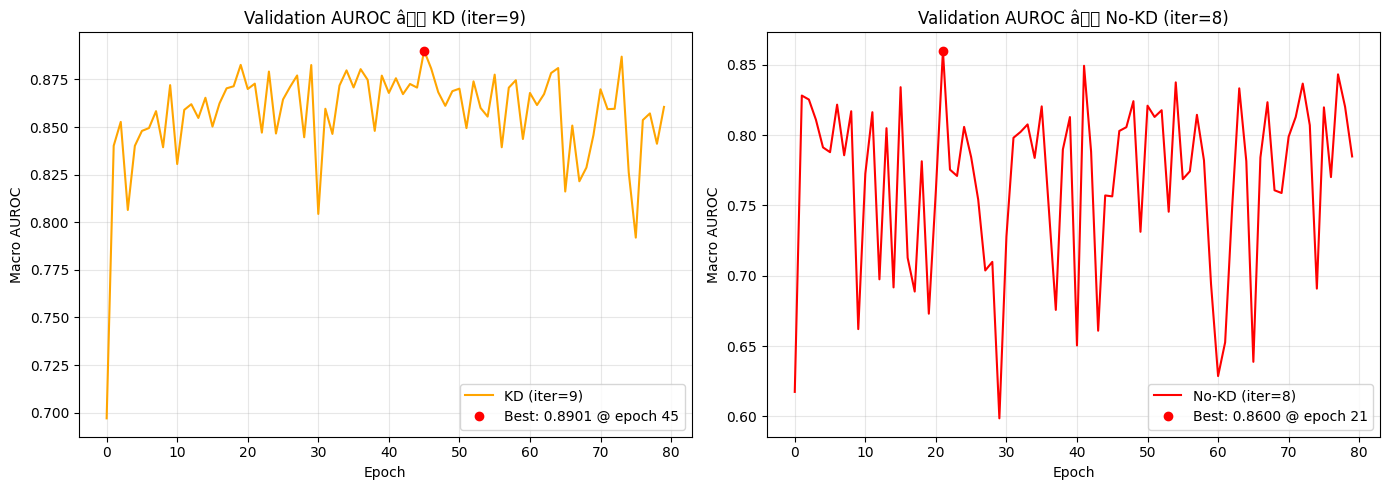

In [24]:
with h5py.File("record_history/metrics.h5", "r") as mh5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (label, it, color) in zip(
        axes,
        [(f"KD (iter={iter_kd})",    iter_kd,   "orange"),
         (f"No-KD (iter={iter_nokd})", iter_nokd, "red")]
    ):
        key = f"valid_score_{it}"
        if key not in mh5:
            ax.set_title(f"{label} â not found")
            continue
        scores = mh5[key][()]
        best_i = int(np.argmax(scores))
        ax.plot(scores, color=color, label=label)
        ax.plot(best_i, scores[best_i], "ro",
                label=f"Best: {scores[best_i]:.4f} @ epoch {best_i}")
        ax.set_title(f"Validation AUROC â {label}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Macro AUROC")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



## Model Testing



In [25]:
from torch.utils.data import TensorDataset, random_split, DataLoader
import matplotlib.pyplot as plt

# build the dataloader once and re-use when running the cell below possibly multiple times.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =============== Build data loaders ==========================================#
tqdm.write("Building data loaders...")
# load data
if set_data == 'S':
    path_to_h5_test = 'test_s.h5'
else:
    path_to_h5_test = 'test_l.h5'




images_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['images'][()], dtype=torch.float32)
labels_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['labels'][()], dtype=torch.float32)
dataset_test = TensorDataset(images_test, labels_test)
len_dataset_test = len(dataset_test)
print(images_test.shape)
# build data loaders
test_dataloader = DataLoader(dataset_test, batch_size=32, shuffle=False)
tqdm.write("Done!\n")



# images_train = torch.tensor(h5py.File('train_50.h5', 'r')['images'][()], dtype=torch.float32)#247
# print(images_train.shape)
# plt.imshow(images_test[5,:,:].squeeze(), cmap="gray")
# print(((images_train[:,:,:]).max()))

Building data loaders...
torch.Size([255, 185, 330])
Done!



In [26]:
# =============== Select iteration to test ================================================#

iter=8

# =============== Define model ================================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""

model = Model()


kd=["_NoKD",""]
path_model ='../../IMAGE_MODEL/model'+ kd[0] + f'_{iter}.pth'
# load stored model parameters
ckpt = torch.load(path_model, map_location=lambda storage, loc: storage)
model.load_state_dict(ckpt['model'])
# put model on device
model.to(device=device)
tqdm.write("Done!\n")

# =============== Evaluate on test ==============================================#
model.eval()
# allocation
test_pred = torch.zeros(len_dataset_test,len(classes))
test_true = torch.zeros(len_dataset_test,len(classes))
# progress bar def
test_pbar = tqdm(test_dataloader, desc="Testing")

# evaluation loop
end=0
for traces in test_pbar:
    # data to device
    labels = traces[1].to(device)
    traces = traces[0].to(device)
    start = end

    with torch.no_grad():
        # Forward pass
        model_output = model(traces)

        # store output
        end = min(start + len(model_output), test_pred.shape[0])
        test_pred[start:end] = torch.nn.Sigmoid()(model_output).detach().cpu()
        test_true[start:end] = labels

test_pbar.close()

# =============== Evaluate on validation ==============================================#
model.eval()
# allocation
valid_pred = torch.zeros(valid_size,len(classes))
valid_true = torch.zeros(valid_size,len(classes))

# progress bar def
valid_pbar = tqdm(valid_dataloader, desc="Validating")

# evaluation loop
end=0
for traces in valid_pbar:
    # data to device
    labels = traces[1].to(device)
    traces = traces[0].to(device)
    start = end
    
    with torch.no_grad():
        # Forward pass
        model_output = model(traces)

        # store output
        end = min(start + len(model_output), valid_pred.shape[0])
        valid_pred[start:end] = torch.nn.Sigmoid()(model_output).detach().cpu()
        valid_true[start:end] = labels

valid_pbar.close()

# =============== Save predictions ============================================#
# Only binary
# soft_pred = np.stack((1-test_pred.numpy(), test_pred.numpy()),axis=1).squeeze()

Define model...
Done!



Testing:   0%|          | 0/8 [00:00<?, ?it/s]

NameError: name 'valid_size' is not defined

In [ ]:

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, brier_score_loss

# Predictions for validation and test
if type(test_pred)!= np.ndarray:
    test_pred = test_pred.detach().cpu().numpy()
if type(test_true)!= np.ndarray:
    test_true = test_true.detach().cpu().numpy()
if type(valid_pred)!= np.ndarray:
    valid_pred = valid_pred.detach().cpu().numpy()
if type(valid_true)!= np.ndarray:
    valid_true = valid_true.detach().cpu().numpy()

def brier_score_per_class(y_true, y_pred_proba):
    """
    Calculate Brier score for each class separately
    """
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    
    n_classes = y_true.shape[1]
    scores = []
    
    for k in range(n_classes):
        score = np.mean((y_pred_proba[:, k] - y_true[:, k]) ** 2)
        scores.append(score)
    
    return np.array(scores)

loss_function = nn.BCELoss()


# Lower is better for these
lg_loss = loss_function(torch.tensor(test_pred), torch.tensor(test_true)).item()
# Also lower is better
brier = brier_score_per_class(y_true=test_true, y_pred_proba=test_pred)
# Higher is better
auc = roc_auc_score(y_true=test_true, y_score=test_pred)
print("log loss:", lg_loss, '\n' "brier score:", brier, '\n' "auroc:", auc, '\n')



# y_true and y_pred are available from the last evaluation loop on the validation set
n_classes = len(classes)
optimal_thresholds = np.zeros(n_classes)
th_list = np.linspace(0.01, 0.99, 100)

print(f'Optimal thresholds:')
for class_i in range(n_classes):
    best_f1 = 0
    best_th = 0.5
    
    for th in th_list:
        class_predictions = (valid_pred[:, class_i] >= th).astype(int)
        class_f1 = f1_score(valid_true[:, class_i], class_predictions)
        
        if class_f1 > best_f1:
            best_f1 = class_f1
            best_th = th
    
    optimal_thresholds[class_i] = best_th
    print(f'{classes[class_i]}: {best_th:.2f}')


# Predictions on Validation after Thresholds
valid_bin_pred_th= np.zeros_like(valid_true)
for class_i in range(n_classes):
    valid_bin_pred_th[:, class_i] = (valid_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on Validation after Thresholds
micro_auroc = roc_auc_score(valid_true, valid_pred, average='micro')
macro_auroc = roc_auc_score(valid_true, valid_pred, average='macro')
micro_f1 = f1_score(valid_true, valid_bin_pred_th, average='micro')
macro_f1 = f1_score(valid_true, valid_bin_pred_th, average='macro')
per_class_f1 = f1_score(valid_true, valid_bin_pred_th, average=None)

print(f"\nValidation Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Per Class F1-score: {per_class_f1}")



# for i in range(10):
#     print(f'{valid_bin_pred_th[i]} = {valid_true[i]} = {valid_pred[i]}')

# Predictions on TEST after Thresholds
test_bin_pred_th= np.zeros_like(test_true)
for class_i in range(n_classes):
    test_bin_pred_th[:, class_i] = (test_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on TEST
micro_auroc_test = roc_auc_score(test_true, test_pred, average='micro')
macro_auroc_test = roc_auc_score(test_true, test_pred, average='macro')
micro_f1_test = f1_score(test_true, test_bin_pred_th, average='micro')
macro_f1_test = f1_score(test_true, test_bin_pred_th, average='macro')
per_class_f1 = f1_score(test_true, test_bin_pred_th, average=None)

print(f"\nTest Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc_test:.4f}")
print(f"Macro Auroc: {macro_auroc_test:.4f}")
print(f"Micro F1-score: {micro_f1_test:.4f}")
print(f"Macro F1-score: {macro_f1_test:.4f}")
print(f"Per Class F1-score: {per_class_f1}")


#### Aditional Metrics

In [ ]:
# Order: No KD, KD, Signal, Naive

specificity_array = np.zeros((n_classes,4))
recall_array = np.zeros((n_classes,4))
PPV_array = np.zeros((n_classes,4))
Bal_acc_array = np.zeros((n_classes,4))

In [ ]:

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Predictions for validation and test
if type(test_pred)!= np.ndarray:
    test_pred = test_pred.detach().cpu().numpy()
if type(test_true)!= np.ndarray:
    test_true = test_true.detach().cpu().numpy()
if type(valid_pred)!= np.ndarray:
    valid_pred = valid_pred.detach().cpu().numpy()
if type(valid_true)!= np.ndarray:
    valid_true = valid_true.detach().cpu().numpy()

test_bin_pred = (test_pred >= 0.5).astype(int)
valid_bin_pred = (valid_pred >= 0.5).astype(int)



# with h5py.File('signal_test_s.h5', 'r') as f:
#     test_true = f['labels'][:]       # or np.array(f['labels'])



# for i in range(10):
#     print(f'{valid_bin_pred[i]} = {valid_true[i]} = {valid_pred[i]}')


# Calculate accuracy on Validation
micro_auroc = roc_auc_score(valid_true, valid_pred, average='micro')
macro_auroc = roc_auc_score(valid_true, valid_pred, average='macro')
micro_f1 = f1_score(valid_true, valid_bin_pred, average='micro')
macro_f1 = f1_score(valid_true, valid_bin_pred, average='macro')

print(f"\nValidation Metrics before Thresholds:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

#Calculate accuracy on Test:

# Calculate accuracy on TEST
micro_auroc_test = roc_auc_score(test_true, test_pred, average='micro')
macro_auroc_test = roc_auc_score(test_true, test_pred, average='macro')
micro_f1_test = f1_score(test_true, test_bin_pred, average='micro')
macro_f1_test = f1_score(test_true, test_bin_pred, average='macro')

print(f"\nTest Metrics before Thresholds:")
print(f"Micro Auroc: {micro_auroc_test:.4f}")
print(f"Macro Auroc: {macro_auroc_test:.4f}")
print(f"Micro F1-score: {micro_f1_test:.4f}")
print(f"Macro F1-score: {macro_f1_test:.4f}\n")


# y_true and y_pred are available from the last evaluation loop on the validation set
n_classes = len(classes)
optimal_thresholds = np.zeros(n_classes)
th_list = np.linspace(0.01, 0.99, 100)

print(f'Optimal thresholds:')
for class_i in range(n_classes):
    best_f1 = 0
    best_th = 0.5
    
    for th in th_list:
        class_predictions = (valid_pred[:, class_i] >= th).astype(int)
        class_f1 = f1_score(valid_true[:, class_i], class_predictions)
        
        if class_f1 > best_f1:
            best_f1 = class_f1
            best_th = th
    
    optimal_thresholds[class_i] = best_th
    print(f'{classes[class_i]}: {best_th:.2f}')


# Predictions on Validation after Thresholds
valid_bin_pred_th= np.zeros_like(valid_bin_pred)
for class_i in range(n_classes):
    valid_bin_pred_th[:, class_i] = (valid_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on Validation after Thresholds
micro_auroc = roc_auc_score(valid_true, valid_pred, average='micro')
macro_auroc = roc_auc_score(valid_true, valid_pred, average='macro')
micro_f1 = f1_score(valid_true, valid_bin_pred_th, average='micro')
macro_f1 = f1_score(valid_true, valid_bin_pred_th, average='macro')
per_class_f1 = f1_score(valid_true, valid_bin_pred_th, average=None)

print(f"\nValidation Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc:.4f}")
print(f"Macro Auroc: {macro_auroc:.4f}")
print(f"Micro F1-score: {micro_f1:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Per Class F1-score: {per_class_f1}")



# for i in range(10):
#     print(f'{valid_bin_pred_th[i]} = {valid_true[i]} = {valid_pred[i]}')

# Predictions on TEST after Thresholds
test_bin_pred_th= np.zeros_like(test_bin_pred)
for class_i in range(n_classes):
    test_bin_pred_th[:, class_i] = (test_pred[:, class_i] >= optimal_thresholds[class_i]).astype(int)

# Calculate accuracy on TEST
micro_auroc_test = roc_auc_score(test_true, test_pred, average='micro')
macro_auroc_test = roc_auc_score(test_true, test_pred, average='macro')
micro_f1_test = f1_score(test_true, test_bin_pred_th, average='micro')
macro_f1_test = f1_score(test_true, test_bin_pred_th, average='macro')
per_class_f1 = f1_score(test_true, test_bin_pred_th, average=None)

print(f"\nTest Metrics after Thresholds:")
print(f"Micro Auroc: {micro_auroc_test:.4f}")
print(f"Macro Auroc: {macro_auroc_test:.4f}")
print(f"Micro F1-score: {micro_f1_test:.4f}")
print(f"Macro F1-score: {macro_f1_test:.4f}")
print(f"Per Class F1-score: {per_class_f1}")


# Specificity and Sensitivity Calculation
from sklearn.metrics import confusion_matrix
print("\nSpecificity and Sensitivity per class on Test set:")
CM= np.zeros((n_classes,4)) # classes, TN, FP, FN, TP
for class_i in range(n_classes):
    tn, fp, fn, tp = confusion_matrix(test_true[:, class_i], test_bin_pred_th[:, class_i]).ravel()
    CM[class_i,0]= tn
    CM[class_i,1]= fp
    CM[class_i,2]= fn
    CM[class_i,3]= tp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    PPV = tp / (tp + fp) if (tp + fp) > 0 else 0
    NPV= tn / (tn + fn) if (tn + fn) > 0 else 0
    Balanced_acc = (recall +specificity)/2
    #vs naive metrics
    y_true = test_true[:, class_i]
    n = len(y_true)

    # majority-class naive classifier
    if np.mean(y_true) >= 0.5:
        # always predict positive
        y_pred = np.ones(n, dtype=int)
    else:
        # always predict negative
        y_pred = np.zeros(n, dtype=int)

       

    #Save in array
    k= 0 #naive, KD, NoKd, Signal
    

    specificity_array[ class_i, k] = specificity
    recall_array[ class_i, k] = recall
    PPV_array[ class_i, k] = PPV
    Bal_acc_array[ class_i, k] = Balanced_acc

np.savetxt('CM_test.csv', CM, delimiter=',', header='TN, FP, FN, TP', comments='')

In [ ]:
print(f"\nSpecificity Array:\n{specificity_array}")
print(f"\nRecall Array:\n{recall_array}")
print(f"\nPPV Array:\n{PPV_array}")
print(f"\nBalanced Accuracy Array:\n{Bal_acc_array}")

In [ ]:
np.savetxt("recall_array.csv", recall_array, delimiter=",")
np.savetxt("PPV_array.csv", PPV_array, delimiter=",")
np.savetxt("Bal_acc_array.csv", Bal_acc_array, delimiter=",")
np.savetxt("f1_array.csv", per_class_f1, delimiter=",")
np.savetxt("specificity_array.csv", specificity_array, delimiter=",")


## Grad-CAM

In [ ]:
# -----------------------------
# Grad-CAM wrapper (REQUIRED)
# -----------------------------
class GradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # x: (N, 1, H, W)  → model expects (N, H, W)
        x = x.squeeze(1)
        return self.model(x)

In [ ]:
import torch
import torch.nn as nn
import h5py
import numpy as np
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Load trained model (UNCHANGED)
# -----------------------------
model = Model()

image_index = 19
KD= [ f"_{4}",f"_{6}",f"_NoKD_{1}" ]

for kd in KD:
    path_model ='../../IMAGE_MODEL/model'+ kd +".pth"

    ckpt = torch.load(path_model, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    model.to(device)
    model.eval()



    wrapped_model = GradCAMWrapper(model).to(device)
    wrapped_model.eval()


    # -----------------------------
    # Target layer
    # -----------------------------
    target_layers = [wrapped_model.model.resnet.layer4]


    # -----------------------------
    # Load grayscale image from HDF5
    # -----------------------------
    h5_path = "test_l.h5"

    
    sel_classes = [1]

    with h5py.File("test_l.h5", "r") as f:
        labels = f["labels"][:]          # (N, 5)
        images = f["images"]             # HDF5 dataset (lazy)

        

        mask = np.any(labels[:, sel_classes] == 1, axis=1)
        indices = np.where(mask)[0]

        image = images[indices[image_index], :, :]
        label= labels[indices[image_index], :]
        pred= model(torch.tensor(image, dtype=torch.float32, device=device)[None, :, :])
        pred= torch.sigmoid(pred).detach().cpu().numpy().squeeze()  

    
    print(f"Predicted probs {kd}:", [f"{v:.6f}" for v in pred.flatten().tolist()])
    # images_test = torch.tensor(h5py.File("test_l.h5", 'r')['images'][()], dtype=torch.float32)
    # plt.imshow(images_test[indices[image_index], :, :].squeeze(), cmap="gray")

    # -----------------------------
    # Build input tensor FOR GRAD-CAM
    # -----------------------------
    input_tensor = torch.tensor(
        image,
        dtype=torch.float32,
        device=device
    )[None, None, :, :]  # (1, 1, H, W)

    


    # -----------------------------
    # Forward pass (for class index)
    # -----------------------------
    with torch.no_grad():
        outputs = wrapped_model(input_tensor)

    class_idx = outputs.argmax(dim=1).item()


    # -----------------------------
    # Grad-CAM
    # -----------------------------
    cam = GradCAM(
        model=wrapped_model,
        target_layers=target_layers
    )

    targets = [ClassifierOutputTarget(class_idx)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets,
    )[0]  # (H, W)


    # -----------------------------
    # Visualization
    # -----------------------------
    img = image.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # grayscale → RGB (for display only)
    img_rgb = np.repeat(img[:, :, None], 3, axis=2)

    cam_image = show_cam_on_image(
        img_rgb,
        grayscale_cam,
        colormap=cv2.COLORMAP_HOT,
        use_rgb=True,
    )

    png_save_path = "gradcam_grayscale"+ kd+".png"
    cv2.imwrite(png_save_path, cam_image)

    

print("True label:", label)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['Accuracy', 'AUROC', 'F1-Score']
models = ['No KD', 'KD', 'Signal']
model_colors = ['#1f77b4', '#2ca02c', '#d62728']  # Blue, Green, Red

# Values (transposed to group by metric)
metric_data = {
    'Accuracy': [0.8649, 0.8751, 0.8817],
    'AUROC': [0.9000, 0.9169, 0.9275],
    'F1-Score': [0.7074, 0.7286, 0.7470]
}

# Create figure
plt.figure(figsize=(10, 6))

# Set positions
x = np.arange(len(metrics))
width = 0.25
positions = [x - width, x, x + width]

# Plot bars
for i, model in enumerate(models):
    model_values = [metric_data['Accuracy'][i], 
                    metric_data['AUROC'][i], 
                    metric_data['F1-Score'][i]]
    plt.bar(positions[i], model_values, width, 
            label=model, color=model_colors[i], edgecolor='black', 
            linewidth=1, alpha=0.9)

# Formatting
plt.xlabel('Evaluation Metric', fontsize=13, fontweight='bold')
plt.ylabel('Score', fontsize=13, fontweight='bold')
plt.title('Model Performance Across Metrics', fontsize=15, fontweight='bold', pad=20)
plt.xticks(x, metrics, fontsize=12)
plt.ylim(0.65, 0.95)
plt.legend(title='Model Type', fontsize=11, title_fontsize=12, 
           framealpha=0.9, loc='upper left')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, model in enumerate(models):
    for j, metric in enumerate(metrics):
        height = metric_data[metric][i]
        plt.text(positions[i][j], height + 0.005, f'{height:.4f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()